# K-Nearest Neighbours (KNN)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from sklearn.pipeline import Pipeline
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    run_stratified_cv,
    run_seed_sweep, SweepResult,
    print_sweep_classification_report,
    print_sweep_performance_summary,
    print_sweep_error_patterns,
    plot_sweep_f1_bar, plot_sweep_confusion_matrix,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=RobustScaler(),
    smote_variant="borderline",
)

pca = PCA(n_components=0.95, random_state=42)
X_train_bal = pca.fit_transform(X_train_bal)
X_test_scaled = pca.transform(X_test_scaled)

class_names, classes, colors = get_class_meta()
print(f"PCA: {len(FEATURES)} features → {X_train_bal.shape[1]} components (95% variance retained)")

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    299
1.0    200
2.0    198
Name: count, dtype: int64
Balanced train shape: (697, 17)
Class weights: {np.int64(0): np.float64(0.7770345596432553), np.int64(1): np.float64(1.1616666666666666), np.int64(2): np.float64(1.1734006734006734)}

Outputs ready for modeling:
  X_train_bal       → (697, 17) (balanced, scaled)
  y_train_bal       → 697 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers
PCA: 17 features → 4 components (95% varianc

## Training

In [3]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
}

grid_knn = run_grid_search(
    KNeighborsClassifier(),
    param_grid,
    X_train_bal,
    y_train_bal,
)
knn = grid_knn.best_estimator_

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)

print("KNN training complete.")
print(f"Best n_neighbors: {grid_knn.best_params_['n_neighbors']}")
print(f"Best weights:     {grid_knn.best_params_['weights']}")
print(f"Best CV F1 Macro: {grid_knn.best_score_:.4f}")

KNN training complete.
Best n_neighbors: 3
Best weights:     distance
Best CV F1 Macro: 0.9341


### Seed-Sweep Evaluation

Grid search above tuned `n_neighbors` and `weights` on `random_state=42` only. The single test F1 macro from one split is a noisy estimate when minority test classes have only 6 mesoplanet and 8 psychroplanet samples. Re-evaluate with the tuned hyperparameters across 50 random splits, capturing per-seed confusion matrices and predicted probabilities.

Two KNN-specific notes for the sweep call:

1. **PCA must refit per seed.** Cell 3 applies `PCA(n_components=0.95)` to the seed=42 training set, but each sweep seed has a different training set with a different covariance structure — so PCA needs to refit too. The sweep wraps KNN in a `Pipeline([("pca", PCA), ("knn", KNeighborsClassifier)])` so both steps refit per seed automatically.
2. **No sweep-aware diagnostic plots.** KNN's `predict_proba` is quantized to fractions of `k` (with `k=3`: 0, 1/3, 2/3, 1.0), so posterior violins would show discrete spikes rather than smooth shapes. The seed=42 internals diagnostics above (decision boundary, k sensitivity, neighbourhood purity) all depend on the specific PCA basis and fitted neighbours from one split, so they stay at seed=42.

In [4]:
sweep_knn = run_seed_sweep(
    lambda cw: Pipeline([
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("knn", KNeighborsClassifier(**grid_knn.best_params_)),
    ]),
    df,
    n_seeds=50,
    scaler_cls=RobustScaler,
    smote_variant="borderline",
    model_name="KNN",
    save_csv="sweep_knn.csv",
    save_pickle="sweep_knn.pkl",
)

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/si

KNN — 50-seed sweep
  F1 macro:    0.4544 ± 0.0254  (SEM 0.0036, min 0.3963, max 0.5142)
  F1 weighted: 0.9454 ± 0.0081
  Captured per-seed: predict_proba
  F1 DataFrame saved to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_knn.csv
  Full SweepResult pickled to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_knn.pkl


## Modeling
### DIAGNOSTIC PLOT 1: Decision Boundary in PCA Space

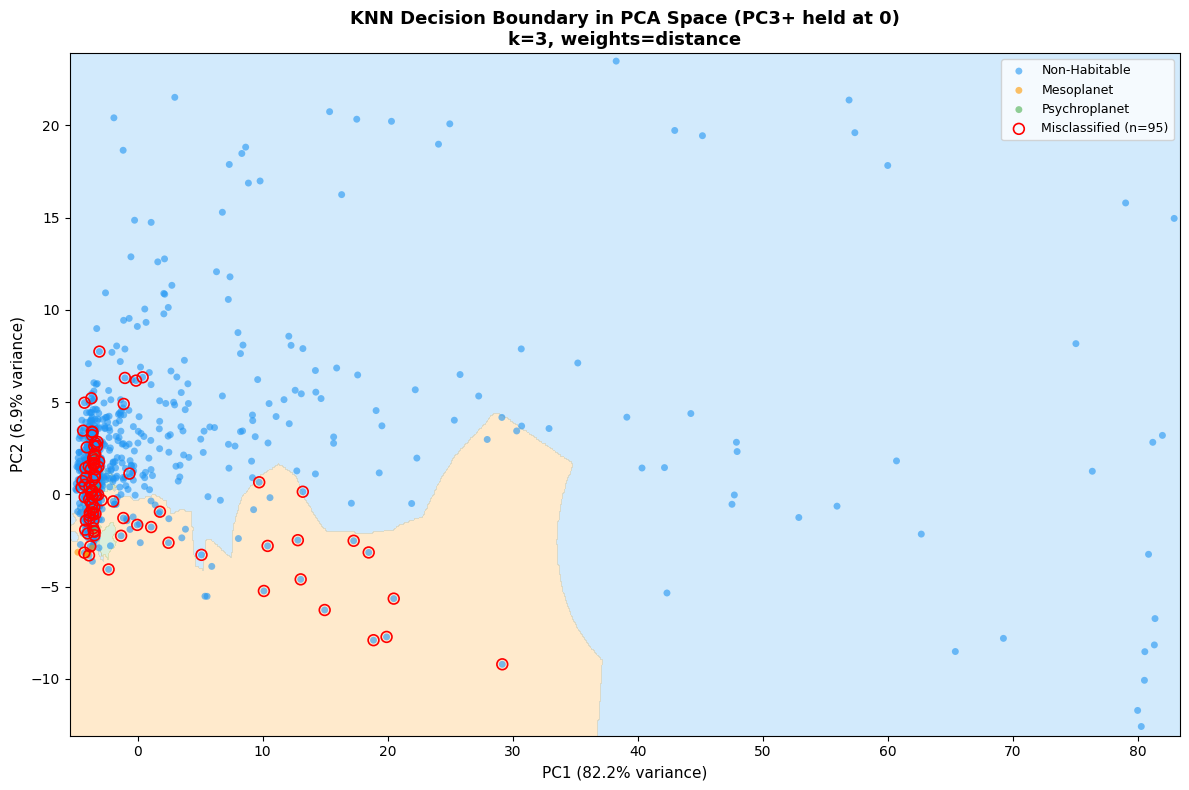

↑ Shaded regions = where KNN assigns each class across PC1/PC2 space.
  PC3+ are held at 0 (their PCA mean) — this is a 2D slice of a higher-dim boundary.
  Red rings = test samples the model got wrong.


In [5]:
n_components = X_train_bal.shape[1]
h = 0.1
x_min, x_max = X_test_scaled[:, 0].min() - 0.5, X_test_scaled[:, 0].max() + 0.5
y_min, y_max = X_test_scaled[:, 1].min() - 0.5, X_test_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

mesh = np.zeros((xx.ravel().shape[0], n_components))
mesh[:, 0] = xx.ravel()
mesh[:, 1] = yy.ravel()
Z = knn.predict(mesh).reshape(xx.shape)

y_test_arr = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)

fig, ax = plt.subplots(figsize=(12, 8))
ax.contourf(xx, yy, Z, alpha=0.2, levels=[-0.5, 0.5, 1.5, 2.5], colors=colors)

for i, (cls, label, color) in enumerate(zip(classes, class_names, colors)):
    mask = y_test_arr == cls
    ax.scatter(X_test_scaled[mask, 0], X_test_scaled[mask, 1],
               c=color, label=label, alpha=0.6, s=25, edgecolors="none")

misclassified = y_pred_knn != y_test_arr
ax.scatter(X_test_scaled[misclassified, 0], X_test_scaled[misclassified, 1],
           facecolors="none", edgecolors="red", s=60, linewidths=1.2,
           label=f"Misclassified (n={misclassified.sum()})", zorder=4)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=11)
ax.set_title(f"KNN Decision Boundary in PCA Space (PC3+ held at 0)\n"
             f"k={knn.n_neighbors}, weights={knn.weights}",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
save_plot("knn_decision_boundary")
plt.show()

print("↑ Shaded regions = where KNN assigns each class across PC1/PC2 space.")
print("  PC3+ are held at 0 (their PCA mean) — this is a 2D slice of a higher-dim boundary.")
print("  Red rings = test samples the model got wrong.")

### DIAGNOSTIC PLOT 2: k vs CV F1 Macro

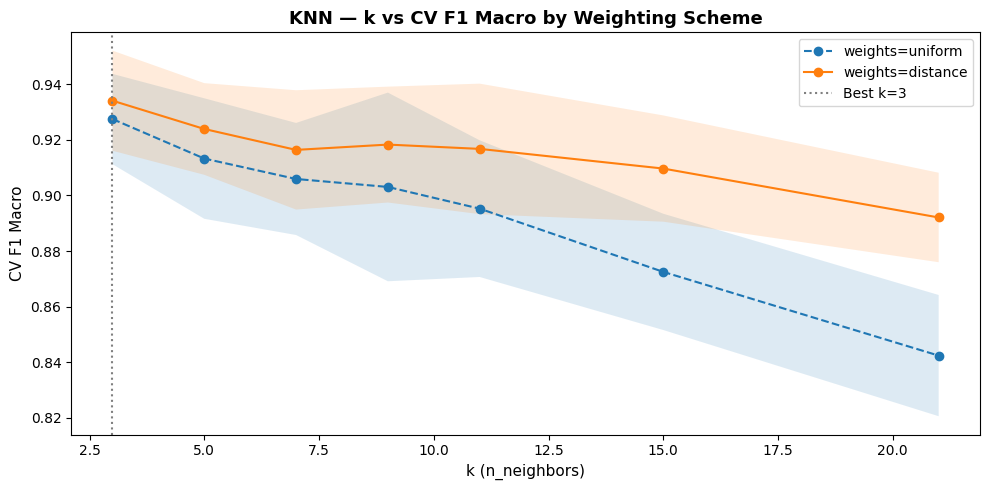

↑ Solid = distance-weighted, dashed = uniform. Shaded band = ±1 std across CV folds.
  Low k = high variance (sensitive to noise), high k = high bias (oversmoothed boundary).


In [6]:
results_df = pd.DataFrame(grid_knn.cv_results_)

fig, ax = plt.subplots(figsize=(10, 5))
for w, ls in [("uniform", "--"), ("distance", "-")]:
    sub = results_df[results_df["param_weights"] == w].sort_values("param_n_neighbors")
    ax.plot(sub["param_n_neighbors"], sub["mean_test_score"],
            marker="o", ls=ls, label=f"weights={w}")
    ax.fill_between(
        sub["param_n_neighbors"],
        sub["mean_test_score"] - sub["std_test_score"],
        sub["mean_test_score"] + sub["std_test_score"],
        alpha=0.15,
    )

ax.axvline(grid_knn.best_params_["n_neighbors"], color="gray", ls=":", lw=1.5,
           label=f"Best k={grid_knn.best_params_['n_neighbors']}")
ax.set_xlabel("k (n_neighbors)", fontsize=11)
ax.set_ylabel("CV F1 Macro", fontsize=11)
ax.set_title("KNN — k vs CV F1 Macro by Weighting Scheme", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("knn_k_sensitivity")
plt.show()

print("↑ Solid = distance-weighted, dashed = uniform. Shaded band = ±1 std across CV folds.")
print("  Low k = high variance (sensitive to noise), high k = high bias (oversmoothed boundary).")

### DIAGNOSTIC PLOT 3: Neighbourhood Purity

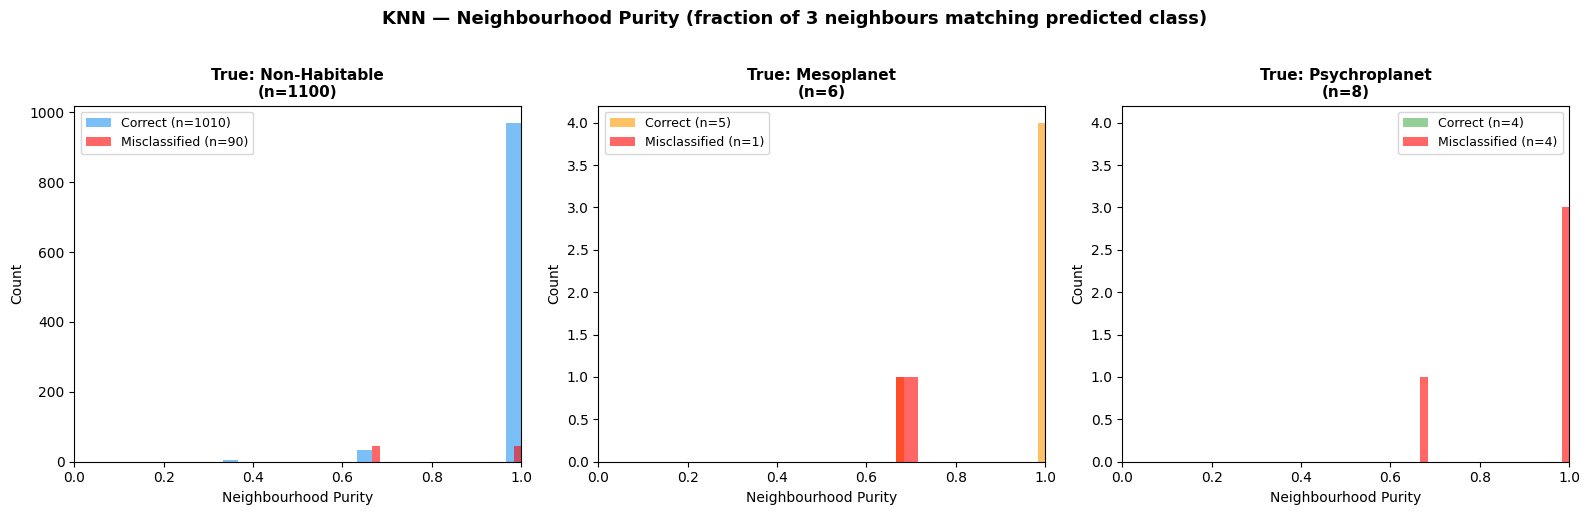

↑ High purity = model is confident — neighbours strongly agree on the predicted class.
  Low purity = mixed neighbourhood — prediction is uncertain.
  Misclassified samples should skew toward lower purity than correct ones.


In [7]:
distances, indices = knn.kneighbors(X_test_scaled)
y_train_arr = y_train_bal.values if hasattr(y_train_bal, "values") else np.asarray(y_train_bal)
y_pred_arr = np.asarray(y_pred_knn)

purity = np.array([
    (y_train_arr[indices[i]] == y_pred_arr[i]).mean()
    for i in range(len(X_test_scaled))
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for true_cls, ax in zip(range(3), axes):
    mask = y_test_arr == float(true_cls)
    correct_mask = mask & (y_pred_arr == y_test_arr)
    wrong_mask   = mask & (y_pred_arr != y_test_arr)

    if correct_mask.sum() > 0:
        ax.hist(purity[correct_mask], bins=20, alpha=0.6,
                color=colors[true_cls], label=f"Correct (n={correct_mask.sum()})")
    if wrong_mask.sum() > 0:
        ax.hist(purity[wrong_mask], bins=20, alpha=0.6,
                color="red", label=f"Misclassified (n={wrong_mask.sum()})")

    ax.set_xlabel("Neighbourhood Purity", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_title(f"True: {class_names[true_cls]}\n(n={mask.sum()})",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle(f"KNN — Neighbourhood Purity (fraction of {knn.n_neighbors} neighbours matching predicted class)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("knn_neighbourhood_purity")
plt.show()

print("↑ High purity = model is confident — neighbours strongly agree on the predicted class.")
print("  Low purity = mixed neighbourhood — prediction is uncertain.")
print("  Misclassified samples should skew toward lower purity than correct ones.")

## Metrics
### Classification Report

KNN — Classification Report (50-seed sweep)
Class               F1 mean     F1 std     F1 min     F1 max
----------------------------------------------------------------
Non-Habitable        0.9549     0.0080     0.9351     0.9701
Mesoplanet           0.2683     0.0681     0.1026     0.4000
Psychroplanet        0.1399     0.0339     0.0638     0.2188
----------------------------------------------------------------
Macro avg            0.4544     0.0254     0.3963     0.5142
Weighted avg         0.9454     0.0081     0.9257     0.9607

5-Fold CV F1 Macro: 0.9353 ± 0.0147

KNN — Performance Summary (50-seed sweep)

Per-class Precision and Recall (mean ± std)
                 Precision            Recall              
Non-Habitable    0.9986 ± 0.0010    0.9150 ± 0.0150
Mesoplanet       0.1657 ± 0.0483    0.7533 ± 0.1757
Psychroplanet    0.0776 ± 0.0197    0.7300 ± 0.1480
----------------------------------------------------------------
Macro avg        0.4140 ± 0.0171    0.7995 ± 0.0673
Wei

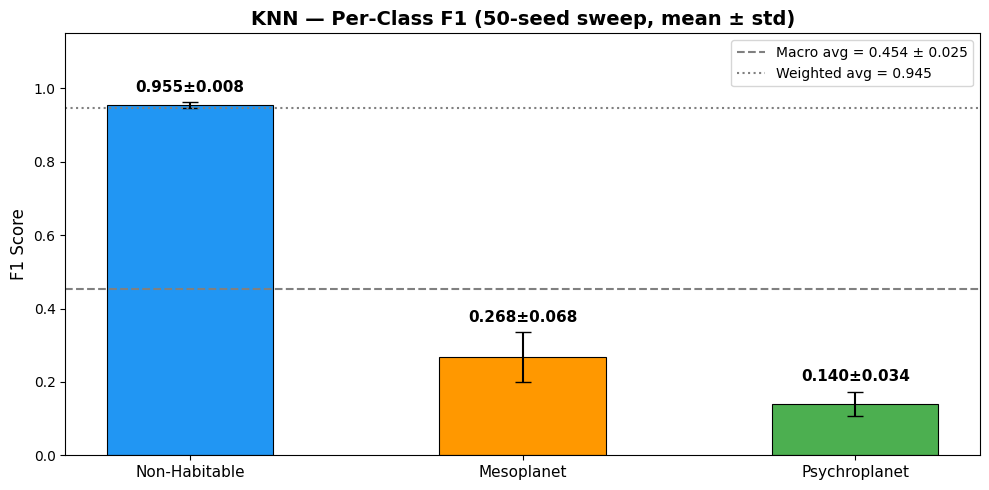

In [8]:
# Per-class F1 with mean ± std from the seed sweep
print_sweep_classification_report(sweep_knn)

# 5-fold CV on the balanced training set — orthogonal to sweep variance,
# measures within-seed tuning stability (different question).
cv_scores_knn = run_stratified_cv(knn, X_train_bal, y_train_bal)

# Cross-model comparison metrics: per-class P/R + aggregate robustness scores
# (MCC, balanced accuracy, minority F1 macro)
print_sweep_performance_summary(sweep_knn)

# Per-class bar chart with error bars from the sweep distribution
plot_sweep_f1_bar(sweep_knn)

### Confusion Matrix (Counts + Normalized)

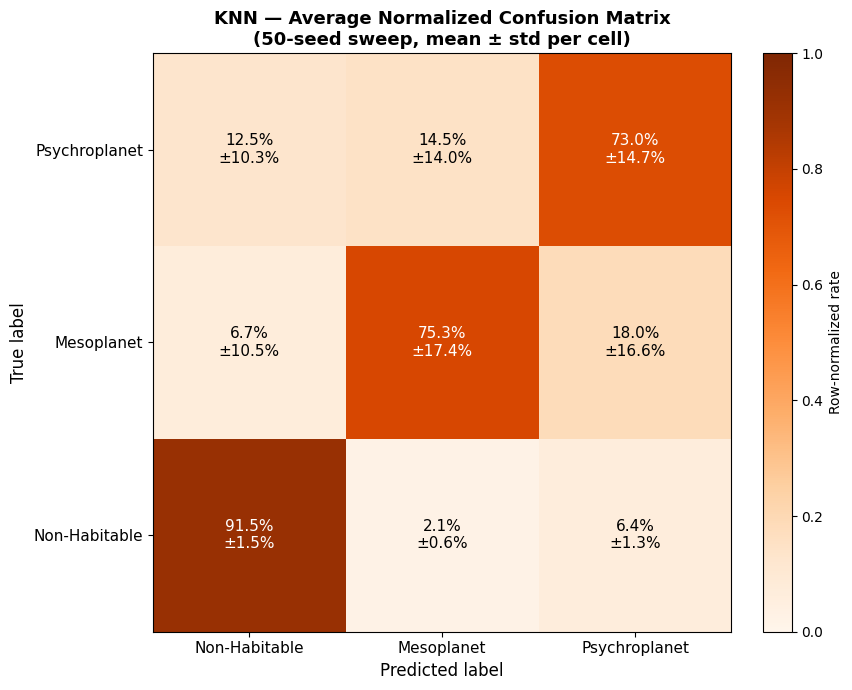

Key error patterns (50-seed sweep):
  Non-Habitable → predicted Mesoplanet: 23.06 ± 7.15 per split  (2.1% ± 0.6% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 70.42 ± 14.54 per split  (6.4% ± 1.3% of true Non-Habitable)
  Mesoplanet → predicted Non-Habitable: 0.40 ± 0.63 per split  (6.7% ± 10.5% of true Mesoplanet)
  Mesoplanet → predicted Psychroplanet: 1.08 ± 1.00 per split  (18.0% ± 16.6% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 1.00 ± 0.82 per split  (12.5% ± 10.3% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 1.16 ± 1.12 per split  (14.5% ± 14.0% of true Psychroplanet)


In [9]:
# Average row-normalized CM across all 50 seeds, annotated per-cell with std
plot_sweep_confusion_matrix(sweep_knn)

# Off-diagonal patterns: per-split count and per-class rate, both mean ± std
print_sweep_error_patterns(sweep_knn)

## Interpretation:
